In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

In [3]:
gold = pd.read_csv('gld_price_data.csv')

In [4]:
gold.head()

,Date,SPX,GLD,USD,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


## Getting some basic information about the data

In [5]:
gold.shape

(2290, 6)

In [6]:
gold.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USD      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [7]:
# getting the statistical measures of the data
gold.describe()

,SPX,GLD,USD,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


## Correlation

In [8]:
gold['Date'] = pd.to_datetime(gold['Date'])  # convert strings to datetime
correlation = gold.drop(columns=['Date']).corr()

<Axes: >

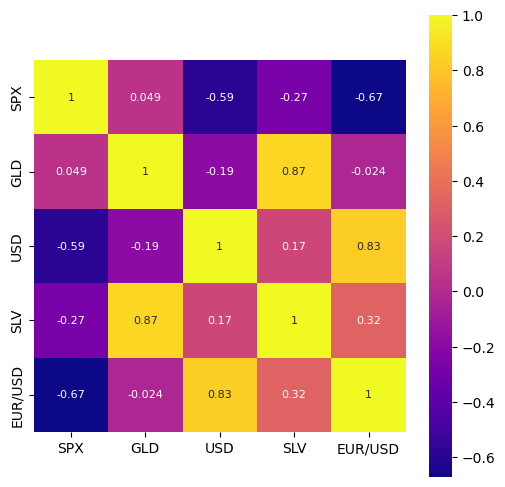

In [9]:
plt.figure(figsize=(6,6))
sns.heatmap(correlation,cbar=True,square=True,annot=True,annot_kws={"size":8},cmap="plasma")

In [10]:
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USD       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


### Checking the Distribution of Gold Price

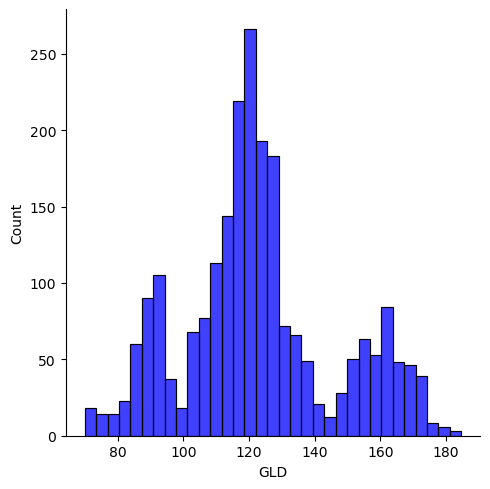

In [11]:
sns.displot(gold['GLD'],color='blue')

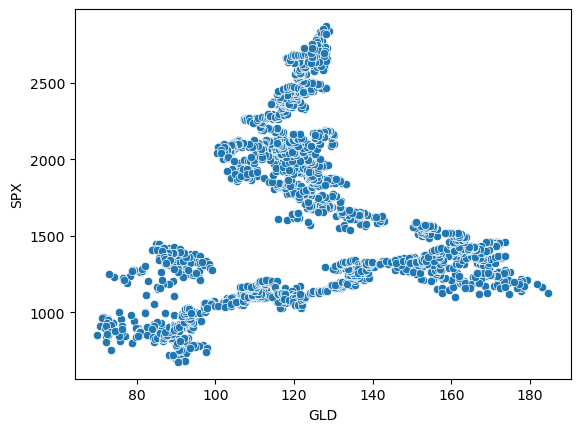

In [12]:
sns.scatterplot(x='GLD', y='SPX',data=gold)
plt.show()

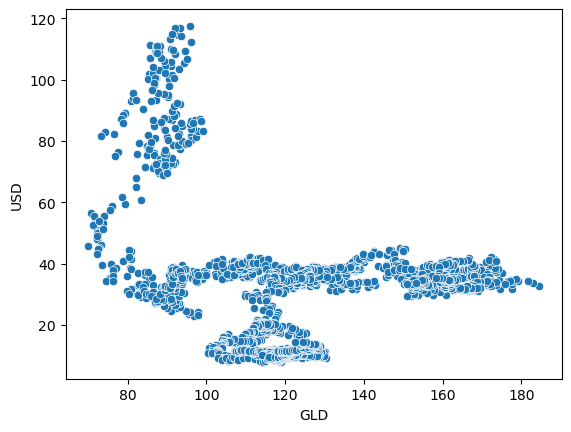

In [13]:
sns.scatterplot(x='GLD', y='USD',data=gold)
plt.show()

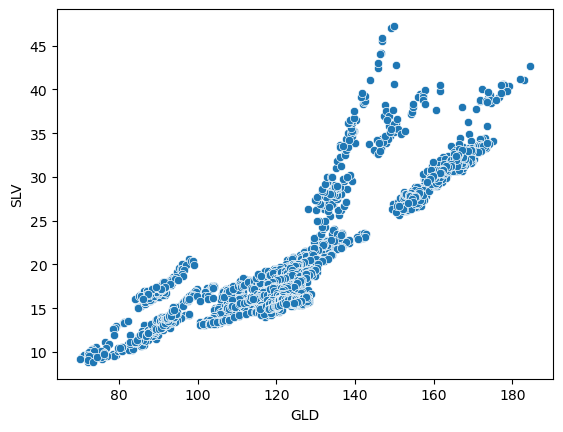

In [14]:
sns.scatterplot(x='GLD', y='SLV',data=gold)
plt.show()

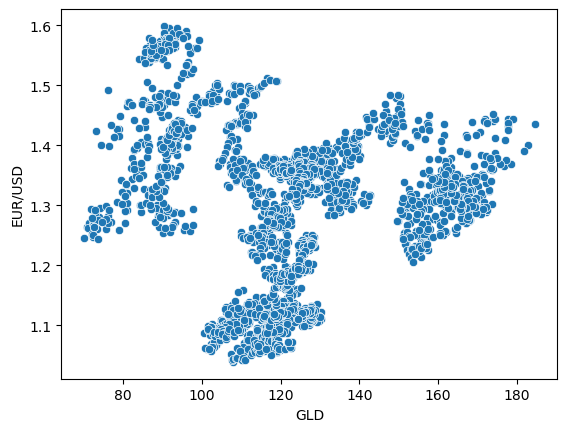

In [15]:
sns.scatterplot(x='GLD', y='EUR/USD',data=gold)
plt.show()

### Splitting the Features and Target

In [16]:
X = gold.drop(['Date','GLD'],axis=1)
y = gold['GLD']

In [17]:
y.shape

(2290,)

## Training the model

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
reg = RandomForestRegressor()
reg.fit(X_train,y_train)
pred = reg.predict(X_test)
print(y_test,)

2178    122.320000
1271    129.899994
1268    126.980003
44       96.500000
2025    117.580002
           ...    
1872    126.680000
1075    167.179993
299      93.849998
306      96.230003
1132    154.339996
Name: GLD, Length: 458, dtype: float64


In [20]:
print("Actual values:", y_test.values)
print("Predicted values:", pred)


Actual values: [122.32     129.899994 126.980003  96.5      117.580002 115.
 125.440002 116.93     108.220001  98.830002  96.910004 168.789993
 151.029999 115.839996 169.809998  85.129997 122.639999 107.849998
 110.449997 131.240005 124.940002 115.379997 116.650002 109.25
 110.529999 125.720001 123.709999 114.949997 114.290001 126.860001
 146.869995  89.440002 167.270004 115.050003 117.110001 120.620003
 141.630005 160.649994 173.309998 152.300003 117.459999 113.150002
 121.309998 113.470001 121.349998 107.519997  88.839996 114.440002
 130.559998 117.739998  99.669998 129.770004 106.169998 161.070007
 127.93     115.940002 143.470001 130.110001  95.730003 124.360001
 116.620003  85.599998 104.099998 112.610001  86.519997 122.400002
 116.470001 112.660004 166.399994  91.989998  80.809998 160.559998
 157.639999 103.419998 135.020004 110.400002 124.43     127.739998
 112.440002 119.910004 137.809998 105.720001  93.559998  92.730003
 111.510002 119.580002 109.980003 111.970001 166.380005 1

In [21]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, pred)
print("R² Score:", r2)


R² Score: 0.9897429973656928


## Prediction System

In [22]:
input_data = (1447.16, 12.34, 15.72, 1.105)  

# Convert to numpy array
input_array = np.asarray(input_data)

# Reshape (1 sample, n features)
reshaped_input = input_array.reshape(1, -1)

# Predict gold price
single_prediction = reg.predict(reshaped_input)
print(f"Predicted Gold Price: {single_prediction[0]}")

Predicted Gold Price: 106.27729954000006


C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
